# ANOVA Analysis

Phân tích phương sai (ANOVA) để so sánh mean của các biến số giữa các nhóm category.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import f_oneway, kruskal

In [7]:
# Load cleaned data
df = pd.read_csv('data/youtube_no_outliers_clean.csv')

numerical_cols = ['duration', 'bitrate', 'bitrate(video)', 'height', 'width',
                  'frame rate', 'frame rate(est.)', 'views', 'likes', 'comments']

## 1. One-Way ANOVA Test

Kiểm tra xem có sự khác biệt về mean giữa các category hay không.

In [9]:
# Thực hiện ANOVA test cho từng biến số
anova_results = []

for col in numerical_cols:
    # Lấy data theo từng category (loại bỏ groups rỗng)
    groups = [df[df['category'] == cat][col].dropna() for cat in df['category'].unique()]
    groups = [g for g in groups if len(g) > 0]  # Chỉ giữ groups có data
    
    # Cần ít nhất 2 groups để test
    if len(groups) < 2:
        continue
    
    try:
        # ANOVA test
        f_stat, p_value = f_oneway(*groups)
        
        # Kruskal-Wallis test (non-parametric alternative)
        h_stat, p_kruskal = kruskal(*groups)
        
        anova_results.append({
            'Variable': col,
            'F-statistic': round(f_stat, 3),
            'p-value (ANOVA)': round(p_value, 6),
            'H-statistic': round(h_stat, 3),
            'p-value (Kruskal)': round(p_kruskal, 6),
            'Significant (α=0.05)': 'Yes' if p_value < 0.05 else 'No'
        })
    except Exception as e:
        print(f"Error with {col}: {e}")

anova_df = pd.DataFrame(anova_results)
anova_df

Error with comments: All numbers are identical in kruskal


,Variable,F-statistic,p-value (ANOVA),H-statistic,p-value (Kruskal),Significant (α=0.05)
0,duration,22.626,0.0,741.415,0.0,Yes
1,bitrate,25.159,0.0,507.847,0.0,Yes
2,bitrate(video),24.993,0.0,511.073,0.0,Yes
3,height,31.904,0.0,592.171,0.0,Yes
4,width,17.323,0.0,366.168,0.0,Yes
5,frame rate,6.192,0.0,192.688,0.0,Yes
6,frame rate(est.),14.211,0.0,214.878,0.0,Yes
7,views,16.423,0.0,529.973,0.0,Yes
8,likes,14.919,0.0,239.827,0.0,Yes


## 2. Boxplot Comparison by Category

Visualize sự khác biệt giữa các category cho từng biến số.

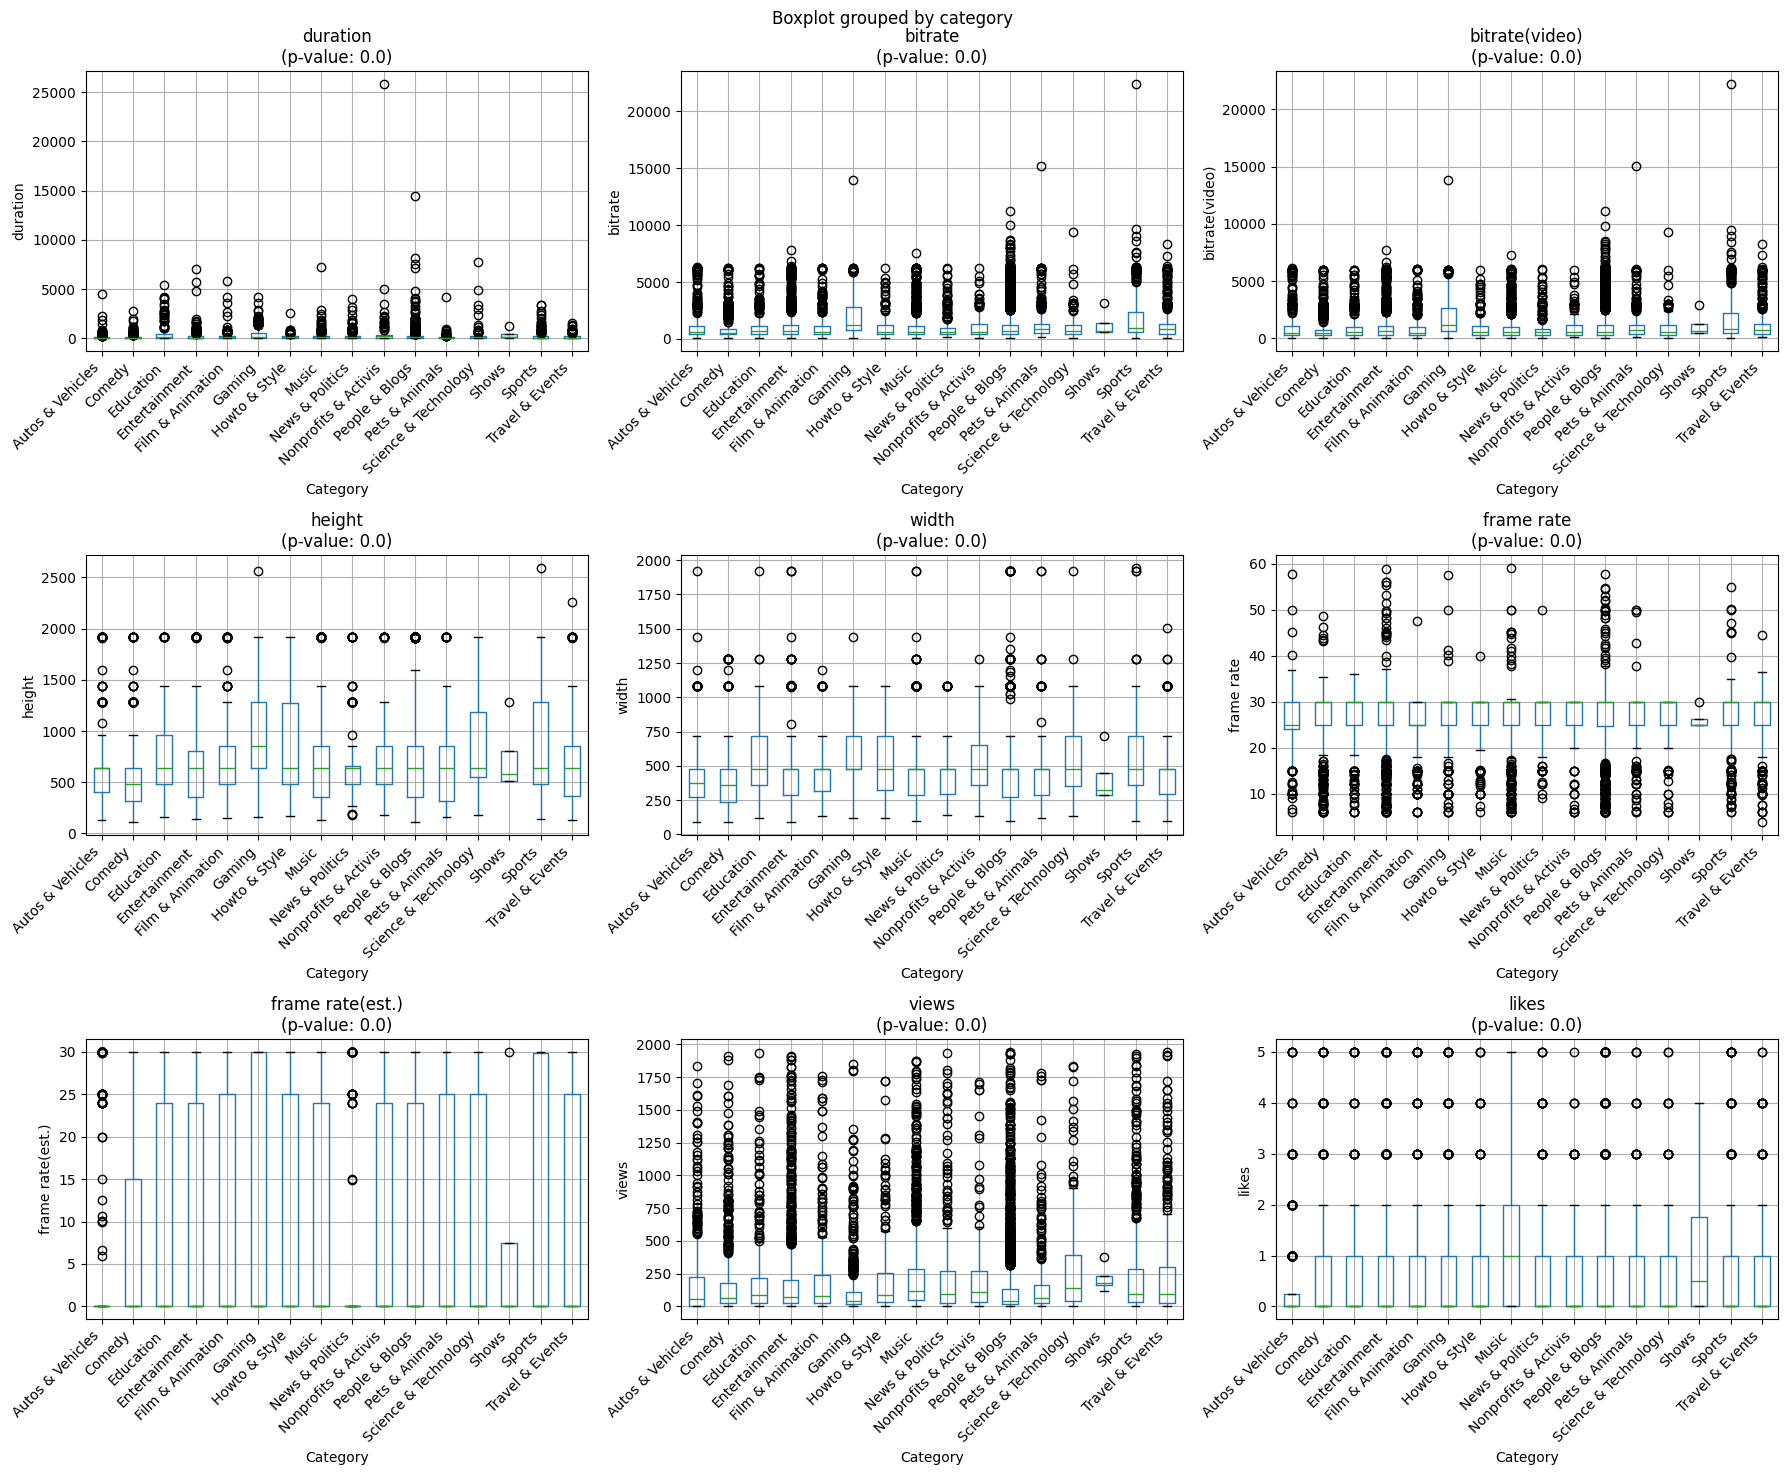

In [10]:
# Boxplot cho các biến có significant difference
significant_vars = anova_df[anova_df['Significant (α=0.05)'] == 'Yes']['Variable'].tolist()

if len(significant_vars) > 0:
    n_vars = len(significant_vars)
    n_cols = 3
    n_rows = (n_vars + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
    fig.suptitle('Boxplot Comparison: Significant Variables by Category', 
                 fontsize=16, fontweight='bold')
    
    axes = axes.flatten() if n_vars > 1 else [axes]
    
    for idx, var in enumerate(significant_vars):
        ax = axes[idx]
        df.boxplot(column=var, by='category', ax=ax)
        ax.set_title(f'{var}\n(p-value: {anova_df[anova_df["Variable"]==var]["p-value (ANOVA)"].values[0]})')
        ax.set_xlabel('Category')
        ax.set_ylabel(var)
        plt.sca(ax)
        plt.xticks(rotation=45, ha='right')
    
    # Hide unused subplots
    for idx in range(len(significant_vars), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No significant differences found between categories")

## 3. Mean Comparison Table

Bảng so sánh mean của các biến số theo category.

In [13]:
# Tạo bảng mean comparison cho significant variables
if len(significant_vars) > 0:
    mean_comparison = df.groupby('category')[significant_vars].mean().round(2)
    print("Mean Comparison by Category:\n")
    print(mean_comparison)
    mean_comparison
else:
    print("No significant variables to compare")

Mean Comparison by Category:

                      duration  bitrate  bitrate(video)  height   width  \
category                                                                  
Autos & Vehicles        120.51  1204.98         1094.73  707.26  456.95   
Comedy                  122.41   862.00          763.33  536.32  420.69   
Education               366.26  1062.13          951.45  774.99  508.32   
Entertainment           176.35  1145.00         1034.05  695.79  467.73   
Film & Animation        212.89  1101.28          975.24  765.32  498.39   
Gaming                  369.97  1803.72         1667.13  982.63  600.39   
Howto & Style           175.76  1075.91          956.57  783.44  499.79   
Music                   216.85  1064.34          950.24  715.65  479.33   
News & Politics         259.97   917.07          804.84  678.29  447.82   
Nonprofits & Activis    564.62  1122.52          976.69  783.52  503.86   
People & Blogs          190.34  1266.36         1156.72  728.66  496.1

## 4. Post-hoc Test: Tukey HSD

Xác định cụ thể cặp category nào khác biệt với nhau (chỉ cho biến significant).

Tukey HSD Test for: duration



C:\Users\Thang Vu\AppData\Roaming\Python\Python314\site-packages\scipy\integrate\_quadpack_py.py:1264: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


                 Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
       group1               group2         meandiff p-adj    lower      upper   reject
--------------------------------------------------------------------------------------
    Autos & Vehicles               Comedy    1.8987    1.0   -82.9816    86.779  False
    Autos & Vehicles            Education  245.7492    0.0   144.1849  347.3135   True
    Autos & Vehicles        Entertainment   55.8423 0.5038   -22.0334   133.718  False
    Autos & Vehicles     Film & Animation   92.3825 0.1763   -13.7587  198.5237  False
    Autos & Vehicles               Gaming  249.4548    0.0   161.2433  337.6664   True
    Autos & Vehicles        Howto & Style   55.2469 0.9883   -76.0719  186.5657  False
    Autos & Vehicles                Music   96.3389 0.0024    18.5239   174.154   True
    Autos & Vehicles      News & Politics  139.4587 0.0002    38.8389  240.0785   True
    Autos & Vehicles Nonprofits & Activis  

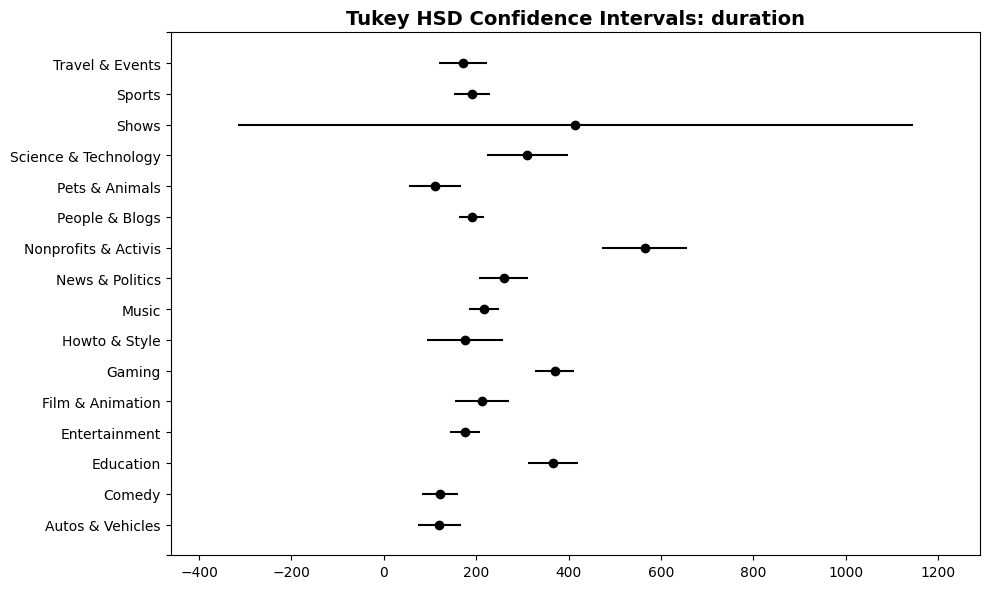

In [15]:
# Thực hiện Tukey HSD test cho 1 biến quan trọng nhất
if len(significant_vars) > 0:
    # Chọn biến có p-value nhỏ nhất
    most_sig_var = anova_df.sort_values('p-value (ANOVA)').iloc[0]['Variable']
    
    print(f"Tukey HSD Test for: {most_sig_var}\n")
    
    # Tukey HSD
    tukey_result = pairwise_tukeyhsd(
        endog=df[most_sig_var],
        groups=df['category'],
        alpha=0.05
    )
    
    print(tukey_result)
    
    # Visualize
    fig = tukey_result.plot_simultaneous(figsize=(10, 6))
    plt.title(f'Tukey HSD Confidence Intervals: {most_sig_var}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No significant variables for post-hoc test")

## 5. Heatmap: Mean Values by Category

Visualize mean values của tất cả numerical variables theo category.

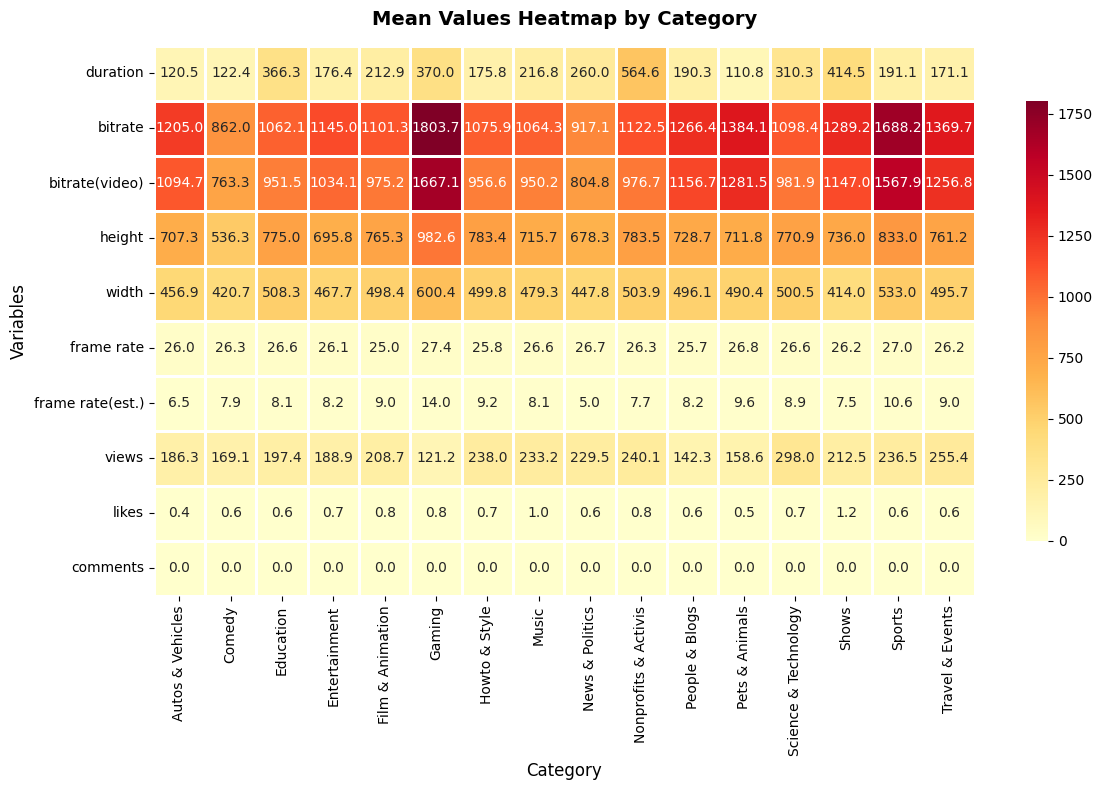

In [16]:
# Heatmap cho mean values
mean_all = df.groupby('category')[numerical_cols].mean()

plt.figure(figsize=(12, 8))
sns.heatmap(mean_all.T, annot=True, fmt='.1f', cmap='YlOrRd', 
            linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Mean Values Heatmap by Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.tight_layout()
plt.show()